# Edge AI Assignment 2: Neural Network from Scratch (Checkerboard Classification)

## Objective
Build a simple neural network **from scratch (no ML libraries)** to classify a 2D checkerboard pattern.

You will:
- Implement forward propagation
- Implement backpropagation
- Train a small neural network
- Visualize the decision boundary

---

## Changes from `assignment_02_claud.ipynb`

This notebook (`assignment_02_claude2.ipynb`) extends the original with the following modifications:

### 1. Updated RUNS Configuration
- All runs now use **10 000 epochs** (up from 2 500–5 000) to give every configuration
  enough time to converge on the 8×8 checkerboard.
- The run list is expanded to **10 configurations** covering sigmoid, ReLU, tanh, and
  leaky ReLU across shallow and deep network architectures, as specified in the assignment.

### 2. Per-Run Plots
The original notebook collected all results first and then produced two combined
overlay charts.  This version adds **immediate per-run diagnostic plots** so you can
see how each configuration converges while the training is still running:

| Panel | What it shows |
|---|---|
| **Loss vs Epochs** | How the training error decreases over time for this specific run |
| **Learning Rate vs Epochs** | How the LR schedule evolves for this run |
| **Decision Boundary** | The spatial boundary the trained network has learned |

The combined overlay charts (all runs on one axes) are still produced at the end
for easy cross-run comparison.

---

## Why "from scratch"?

Libraries like TensorFlow and PyTorch hide the math behind convenient APIs.  Building a
network by hand forces you to understand exactly what is happening at every step — no
magic, just matrix multiplication, derivatives, and loops.

The two core operations are:
- **Forward pass** — run inputs through the network to get a prediction.
- **Backward pass (backpropagation)** — compute how much each weight contributed to the
  error and adjust it accordingly.

We repeat those two steps thousands of times until the network learns the pattern.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## User Configuration

All experiment parameters live in the `RUNS` list below.  Each entry is a
**dictionary** (a set of key-value pairs) that describes one training run:

| Key | What it controls |
|---|---|
| `hidden_layers` | **Array** of hidden layer sizes, e.g. `[32]` = one layer of 32 neurons, `[32, 16, 8]` = three hidden layers |
| `learning_rate` | Initial step size for gradient descent |
| `epochs` | How many complete passes over the training data |
| `lr_decay` | Fraction by which the learning rate is multiplied each epoch.<br>1.0 = no decay; 0.999 = slow decay; 0.99 = faster decay |
| `activation` | Non-linearity used in all hidden layers: `'sigmoid'`, `'relu'`, `'tanh'`, or `'leaky_relu'` |

### Why arrays for `hidden_layers`?

A real neural network can have **more than one hidden layer**.  Each additional layer lets
the network compose simpler features into more complex ones.  For the checkerboard:

- `[64]`         → one hidden layer, 64 neurons — simple, fast
- `[64, 32]`     → two hidden layers — can learn more abstract features
- `[64, 32, 16, 8]` → four hidden layers — deeper network, more capacity

Adding entries to `RUNS` generates as many experiment runs as you like.
All runs execute automatically and their curves are overlaid at the end for easy comparison.

### Why 10 000 epochs?

The 8×8 checkerboard has 64 alternating regions.  A shallow network with 64 hidden neurons
needs many gradient steps to approximate all 64 boundaries.  At 10 000 epochs with
`lr_decay = 0.9995` the learning rate falls to about `lr × 0.9995^10000 ≈ lr × 0.0067`,
giving a warm fast phase early and a fine-tuning slow phase at the end.

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# USER CONFIGURATION  ← edit this section to define your experiments
# ─────────────────────────────────────────────────────────────────────────────
RUNS = [
     {
        "label":         "ReLU, [256,256,64]",
        "hidden_layers": [256,256,64],
        "learning_rate": 0.2,
        "epochs":        20000,
        "lr_decay":      0.99995,
        "activation":    "relu",
    },
    {
        "label":         "leaky ReLU, [256,256,256,64]",
        "hidden_layers": [256,256,256,64],
        "learning_rate": 0.2,
        "epochs":        20000,
        "lr_decay":      0.99995,
        "activation":    "leaky_relu",
    },
]
# ─────────────────────────────────────────────────────────────────────────────

## Step 1: Generate Checkerboard Data

We create 5 000 random 2-D points in the range `[-1, 1]` for both x and y.
A point is labeled **1** or **0** by the checkerboard rule:

```
label = (floor_col + floor_row) mod 2
```

With `k=4`, `(X + 1) * k` maps `[-1, 1]` → `[0, 8]`, so `floor()` creates **8 bins
per axis** — giving an **8×8 grid of 64 alternating squares**.  This is harder than
it sounds: many neural network benchmarks use a 4×4 or even 2×2 checkerboard.

The checkerboard is a classic benchmark because **no straight line can separate the
classes** — a simple linear model will fail here.  A network with at least one
hidden layer can learn the non-linear boundary, but it needs enough neurons and
epochs to approximate all 64 regions.

In [3]:
def generate_data(n_samples=10000, k=4):
    X = np.random.uniform(-1, 1, (n_samples, 2))
    y = ((np.floor((X[:,0]+1)*k) + np.floor((X[:,1]+1)*k)) % 2)
    return X, y.reshape(-1, 1)

X, y = generate_data()

## Visualize Dataset

The scatter plot below shows the two classes in different colors.
Notice the alternating pattern — this is why the problem is called "checkerboard".
Any classifier must learn these alternating regions, which requires a non-linear decision boundary.

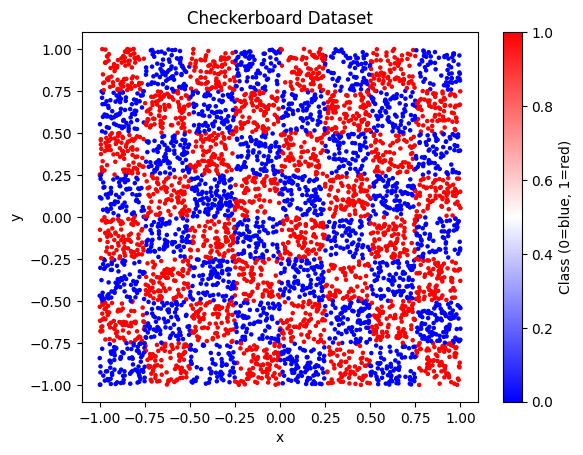

In [4]:
plt.scatter(X[:,0], X[:,1], c=y.flatten(), cmap='bwr', s=5)
plt.title("Checkerboard Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar(label="Class (0=blue, 1=red)")
plt.show()

## Step 2: Build Neural Network

### Architecture

The network supports **arbitrary depth** — you define the hidden layers as an array in `RUNS`.
For `hidden_layers = [32, 16, 8]` the full architecture is:

```
 Input         Hidden 1       Hidden 2       Hidden 3       Output
 (2 neurons)   (32 neurons)   (16 neurons)   (8 neurons)    (1 neuron)

    x ──┐
         ├──► [W1,b1] ──► act ──► [W2,b2] ──► act ──► [W3,b3] ──► act ──► [W4,b4] ──► sigmoid ──► ŷ
    y ──┘
```

### Weight Initialization — He vs Xavier

The initialization std controls how large the initial pre-activations are.
**Getting this wrong causes immediate saturation and near-zero gradients from epoch 0.**

| Activation | Init formula | Why |
|---|---|---|
| ReLU / Leaky ReLU | `sqrt(2 / n_in)` — **He init** | ReLU kills half the neurons; factor-of-2 compensates |
| Sigmoid / Tanh | `sqrt(2 / (n_in + n_out))` — **Xavier init** | Keeps pre-activations in the curve's linear region |

Using He init for sigmoid/tanh pushes neurons into saturation at the start.
Their gradient (max 0.25 for sigmoid) becomes near-zero, and the network barely moves.

`init_params(layer_sizes, activation)` selects the right formula automatically.

In [5]:
def init_params(layer_sizes, activation="relu"):
    """Build weight matrices for a network with the given layer sizes.

    layer_sizes: list like [2, 32, 16, 8, 1]
    activation : selects the initialization formula
                 ReLU/leaky_relu → He init  (std = sqrt(2 / n_in))
                 sigmoid/tanh    → Xavier init (std = sqrt(2 / (n_in + n_out)))

    Returns: list of (W, b) tuples, one per layer transition.
    """
    relu_family = ("relu", "leaky_relu")
    params = []
    for i in range(len(layer_sizes) - 1):
        n_in, n_out = layer_sizes[i], layer_sizes[i + 1]
        if activation in relu_family:
            std = np.sqrt(2.0 / n_in)               # He init — designed for ReLU
        else:
            std = np.sqrt(2.0 / (n_in + n_out))     # Xavier init — designed for sigmoid/tanh
        W = np.random.randn(n_in, n_out) * std
        b = np.zeros((1, n_out))
        params.append((W, b))
    return params

## Activation Functions

An **activation function** introduces non-linearity into the network.  Without it, stacking
layers would still be equivalent to a single linear transformation — we could never fit
the checkerboard.

We support four activation functions so you can compare them across runs:

| Name | Formula | Output range | Notes |
|---|---|---|---|
| **Sigmoid** | `1 / (1 + e^-x)` | (0, 1) | Classic; **gradients vanish in deep networks** |
| **ReLU** | `max(0, x)` | [0, ∞) | Fast to train; "dead neuron" risk |
| **Tanh** | `tanh(x)` | (−1, 1) | Zero-centered; better than sigmoid for depth |
| **Leaky ReLU** | `x if x>0 else 0.01x` | (−∞, ∞) | Fixes the dead-neuron problem of ReLU |

The output layer always uses **sigmoid** because we need a probability in (0, 1).

### Why sigmoid struggles in deep networks — gradient vanishing

The sigmoid derivative is `a * (1 - a)`, which peaks at **0.25** (when `a = 0.5`).
Each hidden sigmoid layer multiplies the flowing gradient by at most 0.25.

With 3 hidden layers: `0.25³ ≈ 0.016` — the first layer receives only **1.6%** of
the output-layer gradient.  It barely learns.  Adding more sigmoid layers makes
convergence *worse*, not better.

**For networks with more than one hidden layer, prefer ReLU, tanh, or leaky_relu.**
ReLU's derivative is 0 or 1, so gradients don't shrink as they pass through the layer.

### Derivatives — why we need them

During backpropagation the chain rule requires the derivative of each activation.
All derivative functions here accept the **post-activation value** (the output of the
activation), not the pre-activation.  Each formula is exact for its activation:

| Activation | Post-activation `a` | Derivative formula |
|---|---|---|
| Sigmoid | `sigmoid(z)` | `a * (1 - a)` |
| ReLU | `relu(z) = max(0,z)` | `1 if a > 0 else 0` (equivalent to `z > 0`) |
| Tanh | `tanh(z)` | `1 - a²` |
| Leaky ReLU | `z if z>0 else 0.01z` | `1 if a > 0 else 0.01` |

`get_activation(name)` returns a `(forward_fn, derivative_fn)` pair.

In [6]:
# ── Sigmoid ──────────────────────────────────────────────────────────────────
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_deriv(a):
    # a is the POST-activation value; derivative = a * (1 - a)
    return a * (1 - a)

# ── ReLU ─────────────────────────────────────────────────────────────────────
def relu(x):
    return np.maximum(0, x)

def relu_deriv(a):
    # a is the POST-activation value from relu; derivative = 1 where a > 0
    return (a > 0).astype(float)

# ── Tanh ─────────────────────────────────────────────────────────────────────
def tanh_act(x):
    return np.tanh(x)

def tanh_deriv(a):
    # a is the POST-activation value from tanh; derivative = 1 - a^2
    return 1 - a ** 2

# ── Leaky ReLU ───────────────────────────────────────────────────────────────
LEAKY_ALPHA = 0.01

def leaky_relu(x):
    return np.where(x > 0, x, LEAKY_ALPHA * x)

def leaky_relu_deriv(a):
    # For leaky relu the derivative depends on the PRE-activation sign,
    # but we approximate via the post-activation value (works when alpha << 1)
    return np.where(a > 0, 1.0, LEAKY_ALPHA)

# ── Dispatcher ───────────────────────────────────────────────────────────────
def get_activation(name):
    """Return (forward_fn, derivative_fn) for the named activation."""
    table = {
        "sigmoid":    (sigmoid,    sigmoid_deriv),
        "relu":       (relu,       relu_deriv),
        "tanh":       (tanh_act,   tanh_deriv),
        "leaky_relu": (leaky_relu, leaky_relu_deriv),
    }
    if name not in table:
        raise ValueError(f"Unknown activation '{name}'. Choose from: {list(table)}")
    return table[name]

## Forward Pass

The forward pass feeds inputs through **every layer** in sequence to produce a prediction.

For a network with layers `[2, 32, 16, 8, 1]`, four transitions happen:

```
A0 = X                                          # shape: (n, 2)  — the raw inputs

Z1 = A0 @ W1 + b1;   A1 = activation(Z1)       # shape: (n, 32)
Z2 = A1 @ W2 + b2;   A2 = activation(Z2)       # shape: (n, 16)
Z3 = A2 @ W3 + b3;   A3 = activation(Z3)       # shape: (n, 8)
Z4 = A3 @ W4 + b4;   A4 = sigmoid(Z4)          # shape: (n, 1)  — probability
```

`Z` is the **pre-activation** (the raw linear combination) and `A` is the
**post-activation** (after the non-linear function is applied).

We store **every `(Z, A)` pair** in a `cache` list because backpropagation needs
them to compute gradients.

### Key change from original
The original called `np.sigmoid()` which does not exist in NumPy.
`forward` now loops over an arbitrary list of `(W, b)` parameter pairs, applies
the chosen hidden activation to every hidden layer, and always uses `sigmoid` at
the output layer.

In [7]:
def forward(X, params, activation_fn=sigmoid):
    """Run a forward pass through a network of arbitrary depth.

    params        : list of (W, b) tuples from init_params
    activation_fn : applied to every hidden layer; output layer always uses sigmoid

    Returns: list of (Z, A) pairs — pre- and post-activation — for every layer.
    """
    cache = []
    A = X                           # start with the raw input
    num_layers = len(params)

    for i, (W, b) in enumerate(params):
        Z = np.dot(A, W) + b        # linear combination
        is_output = (i == num_layers - 1)
        A = sigmoid(Z) if is_output else activation_fn(Z)   # non-linearity
        cache.append((Z, A))        # save both for backprop

    return cache                    # cache[i] = (Z_i, A_i) for layer i+1

## Loss Function — Binary Cross-Entropy

The loss (or cost) measures **how wrong** the network's predictions are.

For binary classification the standard choice is **Binary Cross-Entropy (BCE)**:

$$L = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i) \right]$$

Intuition:
- When the true label `y = 1`: the loss is `−log(ŷ)`.  Confident correct prediction (`ŷ ≈ 1`) → near zero; wrong prediction (`ŷ ≈ 0`) → large penalty.
- When `y = 0`: the loss is `−log(1 − ŷ)`.  Same logic in reverse.

We clip predictions away from 0 and 1 to avoid `log(0) = -∞`.

In [8]:
def compute_loss(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-9, 1 - 1e-9)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

## Backpropagation

Backpropagation applies the **chain rule** backwards through every layer to compute
how much each weight contributed to the loss.

### Step-by-step for an L-layer network

**Step 1 — Output layer delta:**

BCE loss + sigmoid output combine so the gradient simplifies to:

$$\delta_L = \frac{\hat{y} - y}{n}$$

**Step 2 — For each layer going backwards (from L-1 down to 0):**

```
A_prev  = previous layer's post-activation (or X for the first layer)
W, b    = current layer's weights

dW  = A_prev.T  @  delta          # gradient for the weight matrix
db  = sum(delta, axis=0)           # gradient for the bias

# Propagate error signal to the layer below:
delta_new = (delta @ W.T) * activation_deriv(A_prev)
```

The key insight: `delta @ W.T` moves the error signal back through the current
weight matrix (reversing the forward dot product), and multiplying by
`activation_deriv(A_prev)` accounts for how much the previous layer's activation
"passed through" vs "blocked" the signal.

### Change from original
- The original `backward` was a placeholder (`pass`).
- This implementation loops over **all layers** in reverse, so it works for any
  network depth defined in `RUNS["hidden_layers"]`.
- `activation_deriv_fn` is a parameter so the correct derivative for the chosen
  hidden activation is used automatically.

In [9]:
def backward(X, y, params, cache, activation_deriv_fn=sigmoid_deriv):
    """Backpropagation through a network of arbitrary depth.

    Returns list of (dW, db) tuples in the same order as params.
    """
    n = X.shape[0]
    num_layers = len(params)
    grads = [None] * num_layers

    # Output layer: combined BCE + sigmoid gradient → (ŷ - y) / n
    _, A_out = cache[-1]
    delta = (A_out - y) / n

    for i in reversed(range(num_layers)):
        # Previous layer's activations (or the raw input X for layer 0)
        A_prev = cache[i - 1][1] if i > 0 else X
        W, b = params[i]

        dW = np.dot(A_prev.T, delta)
        db = np.sum(delta, axis=0, keepdims=True)
        grads[i] = (dW, db)

        if i > 0:
            # Propagate error back through this layer's weights,
            # then scale by how much the previous hidden activation passed through
            delta = np.dot(delta, W.T) * activation_deriv_fn(A_prev)

    return grads

## Training Loop

Training repeats four steps on every **epoch** (one full pass over the data):

```
1. Forward pass  → produce predictions ŷ
2. Compute loss  → measure the error
3. Backward pass → compute gradients dW, db for every layer
4. Update weights:
       W  ←  W  −  lr · dW     (for every layer)
       b  ←  b  −  lr · db
```

### Learning rate decay

A fixed learning rate can overshoot the minimum in late training.
**Exponential decay** reduces the learning rate by a constant factor each epoch:

$$lr_{t} = lr_0 \cdot \text{decay}^{t}$$

- `lr_decay = 1.0` → no decay (constant learning rate).
- `lr_decay = 0.999` → halves the LR roughly every 700 epochs.
- `lr_decay = 0.99` → halves the LR roughly every 70 epochs (aggressive).

### What `train()` accepts and returns

`hidden_layers` is now a **list**, e.g. `[32, 16, 8]`.  The function prepends 2 (the
input size) and appends 1 (the output size) to build the full `layer_sizes` list passed
to `init_params`.

Returns:
- `params` — list of trained `(W, b)` tuples, one per layer
- `loss_history` — loss value at every epoch (for the loss plot)
- `lr_history`   — learning rate at every epoch (for the LR plot)

In [10]:
def train(X, y, hidden_layers=32, lr=0.1, epochs=5000, lr_decay=1.0, activation="sigmoid"):
    if isinstance(hidden_layers, int):
        hidden_layers = [hidden_layers]

    layer_sizes = [2] + list(hidden_layers) + [1]
    act_fn, act_deriv_fn = get_activation(activation)
    # Pass activation name so init_params picks He vs Xavier correctly
    params = init_params(layer_sizes, activation=activation)

    loss_history = []
    lr_history   = []
    current_lr   = lr

    for epoch in range(epochs):
        cache = forward(X, params, activation_fn=act_fn)
        _, final_output = cache[-1]

        loss = compute_loss(y, final_output)

        grads = backward(X, y, params, cache, activation_deriv_fn=act_deriv_fn)

        params = [(W - current_lr * dW, b - current_lr * db)
                  for (W, b), (dW, db) in zip(params, grads)]

        loss_history.append(loss)
        lr_history.append(current_lr)
        current_lr *= lr_decay

        if epoch % 500 == 0:
            print(f"  Epoch {epoch:5d} | loss: {loss:.4f} | lr: {current_lr:.6f}")

    return params, loss_history, lr_history

## Visualize Decision Boundary

To see what the trained network learned, we create a fine 200×200 grid covering
`[-1, 1] × [-1, 1]`, run a forward pass on every grid point, and colour each point
by the predicted probability.

- **Blue region** → predicted class 0 (P < 0.5)
- **Red region**  → predicted class 1 (P > 0.5)
- The **contour at 0.5** is the **decision boundary** — where the network is exactly
  50/50 between the two classes.

A well-trained network on the checkerboard will show a grid-like pattern of alternating
red and blue regions, approximating the true checkerboard squares.

### Key change from original
The original `plot_decision_boundary` filled `Z` with zeros and never ran the model,
so the plot was always flat blue.  The function now accepts a `params` list and calls
`forward()` on the grid to get real predictions.

In [11]:
def plot_decision_boundary(X, y, params, activation_fn=sigmoid, title="Decision Boundary", ax=None):
    """Plot the decision boundary of a trained network.

    If ax is provided, draws into that Axes object (for embedding in a multi-panel figure).
    Otherwise creates a new figure.
    """
    xx, yy = np.meshgrid(np.linspace(-1, 1, 200), np.linspace(-1, 1, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]

    cache = forward(grid, params, activation_fn=activation_fn)
    Z = cache[-1][1]            # output layer's post-activation probabilities
    Z = Z.reshape(xx.shape)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 6))

    ax.contourf(xx, yy, Z, levels=50, cmap='bwr', alpha=0.6)
    ax.scatter(X[:,0], X[:,1], c=y.flatten(), cmap='bwr', s=3, edgecolors='none')
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    if standalone:
        plt.tight_layout()
        plt.show()

## Run Training

This section loops through every entry in `RUNS`, trains a network with those settings,
then immediately produces **three diagnostic plots for that run**:

1. **Loss vs Epochs** — how the training error decreases.  Starts near ln(2) ≈ 0.693
   (the loss when predicting 50/50 randomly) and should fall steadily toward zero.
2. **Learning Rate vs Epochs** — the LR schedule for this run.  A smooth downward
   slope confirms exponential decay is active.
3. **Decision Boundary** — the spatial boundary the trained network learned.  A
   well-trained network shows an alternating grid matching the checkerboard.

After all runs finish, two **combined overlay charts** are drawn so you can compare
convergence speed and final loss across all configurations at once.

### Reading the loss curve
- Loss starts near **0.69** (≈ ln 2) — the value when the network is guessing randomly
  (50/50 for a balanced dataset).
- A **steeply falling** curve means the network is learning fast.
- A **flat** curve means the learning rate may be too small, or the network has converged.
- An **increasing** curve means the learning rate is too large (overshoot).

### Change from original
The original notebook collected all results first, then showed two combined overlay
charts.  This version **adds per-run inline plots** (loss + LR + decision boundary
in a single three-panel figure) immediately after each run completes, so you can
diagnose problems without waiting for all runs to finish.


Run: ReLU, [256,256,64]
  hidden=[256, 256, 64]  lr=0.2  epochs=40000  decay=0.99995  activation=relu
  Epoch     0 | loss: 0.7237 | lr: 0.199990
  Epoch   500 | loss: 0.6715 | lr: 0.195052
  Epoch  1000 | loss: 0.6466 | lr: 0.190236
  Epoch  1500 | loss: 0.6141 | lr: 0.185539
  Epoch  2000 | loss: 0.5909 | lr: 0.180958
  Epoch  2500 | loss: 0.5915 | lr: 0.176490
  Epoch  3000 | loss: 0.5459 | lr: 0.172132
  Epoch  3500 | loss: 0.5157 | lr: 0.167882
  Epoch  4000 | loss: 0.4974 | lr: 0.163737
  Epoch  4500 | loss: 0.4489 | lr: 0.159694
  Epoch  5000 | loss: 0.4535 | lr: 0.155751
  Epoch  5500 | loss: 0.4046 | lr: 0.151906
  Epoch  6000 | loss: 0.3928 | lr: 0.148155
  Epoch  6500 | loss: 0.3670 | lr: 0.144497
  Epoch  7000 | loss: 0.3818 | lr: 0.140929
  Epoch  7500 | loss: 0.3314 | lr: 0.137450
  Epoch  8000 | loss: 0.3152 | lr: 0.134056
  Epoch  8500 | loss: 0.2933 | lr: 0.130746
  Epoch  9000 | loss: 0.2909 | lr: 0.127518
  Epoch  9500 | loss: 0.2579 | lr: 0.124369
  Epoch 10000 | l

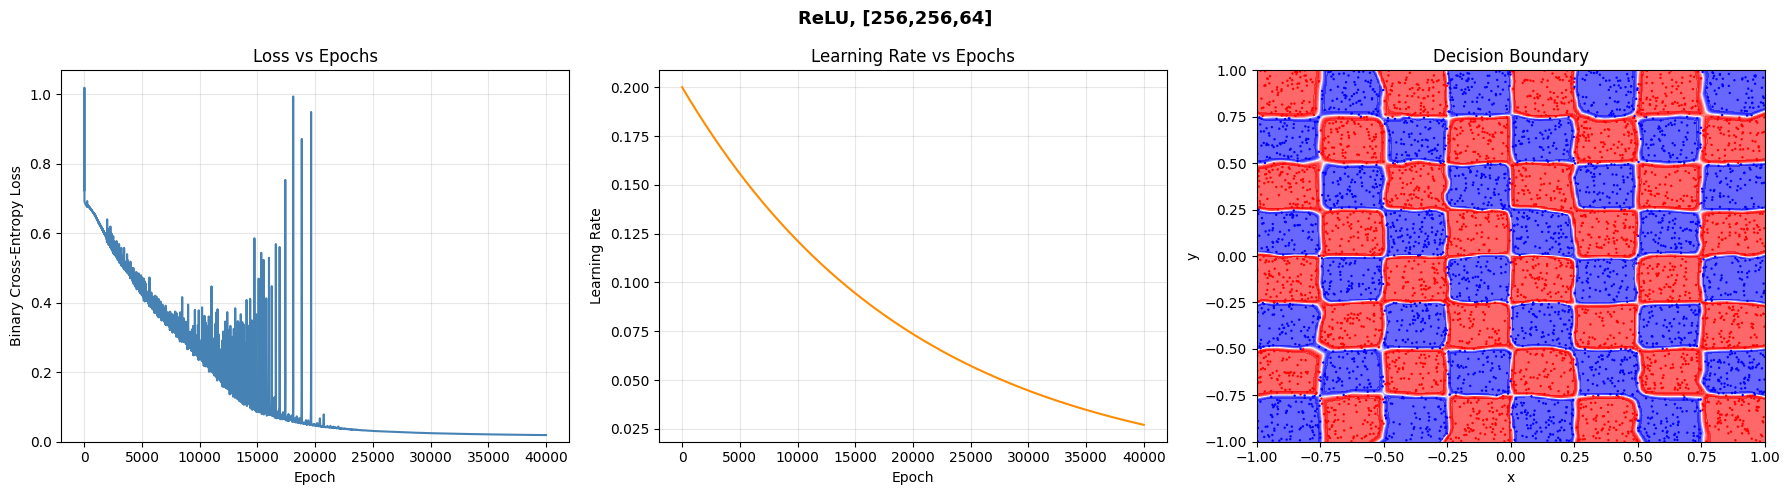


Run: leaky ReLU, [256,256,64]
  hidden=[256, 256, 64]  lr=0.2  epochs=40000  decay=0.99995  activation=leaky_relu
  Epoch     0 | loss: 0.7331 | lr: 0.199990
  Epoch   500 | loss: 0.6688 | lr: 0.195052
  Epoch  1000 | loss: 0.6494 | lr: 0.190236
  Epoch  1500 | loss: 0.6204 | lr: 0.185539
  Epoch  2000 | loss: 0.5870 | lr: 0.180958
  Epoch  2500 | loss: 0.5779 | lr: 0.176490
  Epoch  3000 | loss: 0.5513 | lr: 0.172132
  Epoch  3500 | loss: 0.4878 | lr: 0.167882
  Epoch  4000 | loss: 0.4482 | lr: 0.163737
  Epoch  4500 | loss: 0.4302 | lr: 0.159694
  Epoch  5000 | loss: 0.4088 | lr: 0.155751
  Epoch  5500 | loss: 0.4143 | lr: 0.151906
  Epoch  6000 | loss: 0.3638 | lr: 0.148155
  Epoch  6500 | loss: 0.3408 | lr: 0.144497
  Epoch  7000 | loss: 0.3686 | lr: 0.140929
  Epoch  7500 | loss: 0.3280 | lr: 0.137450
  Epoch  8000 | loss: 0.3145 | lr: 0.134056
  Epoch  8500 | loss: 0.2994 | lr: 0.130746
  Epoch  9000 | loss: 0.2859 | lr: 0.127518
  Epoch  9500 | loss: 0.2564 | lr: 0.124369
  Epo

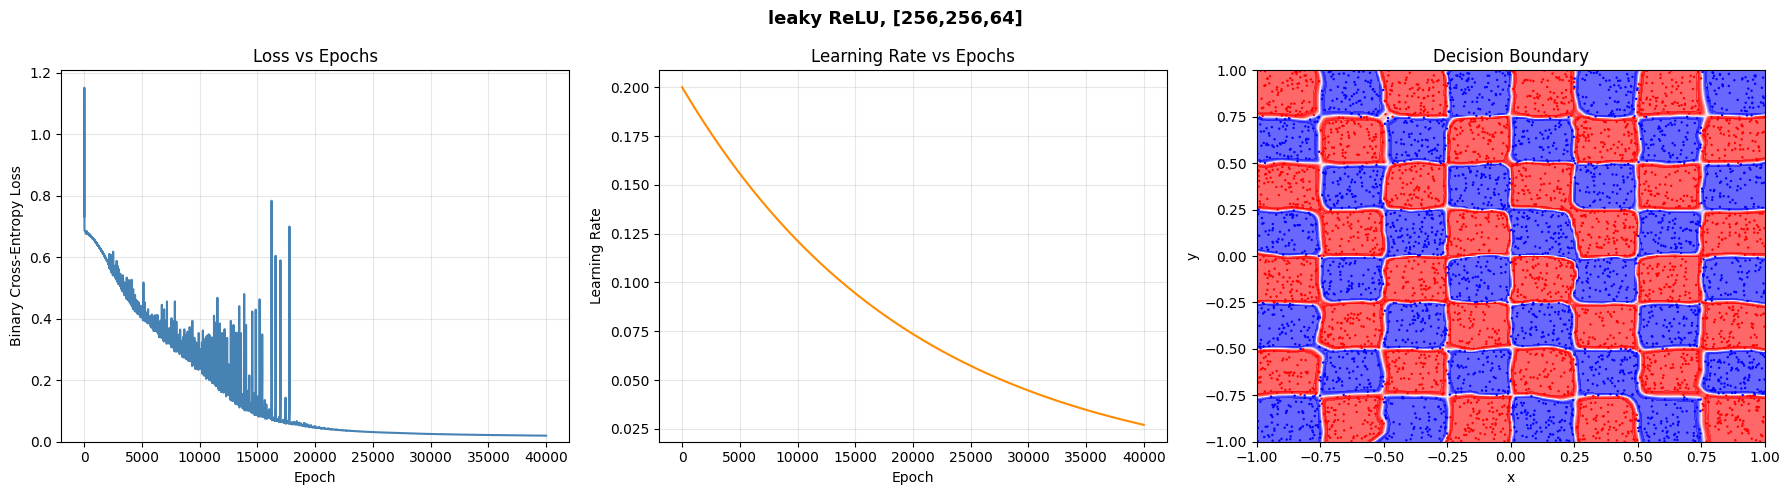

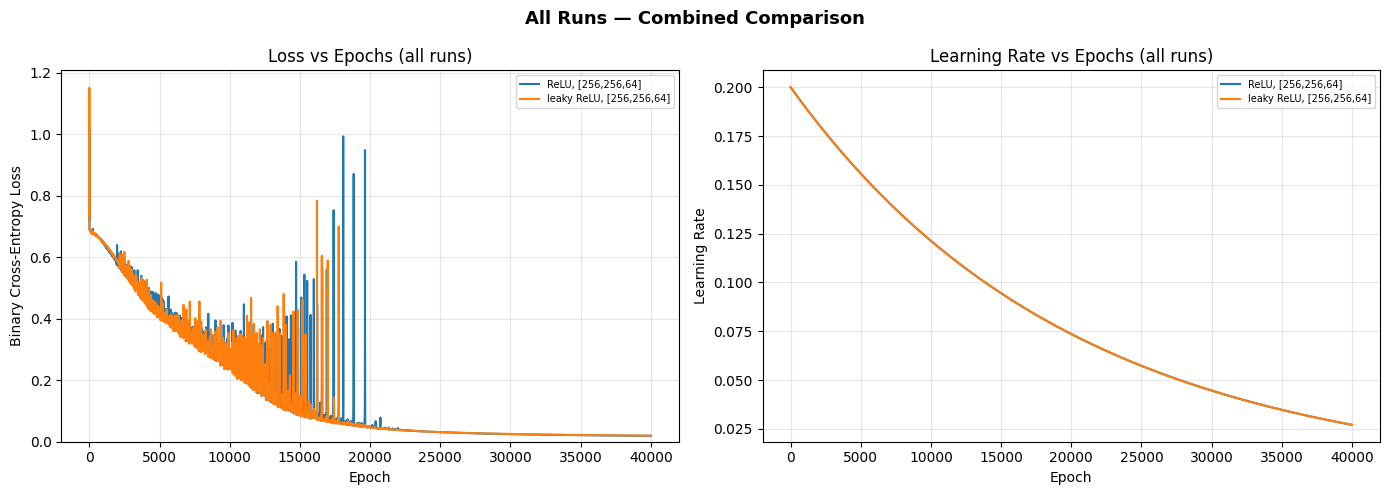

In [12]:
all_results = []   # store (run_cfg, params, loss_hist, lr_hist) for each run

for run in RUNS:
    print(f"\n{'='*60}")
    print(f"Run: {run['label']}")
    print(f"  hidden={run['hidden_layers']}  lr={run['learning_rate']}  "
          f"epochs={run['epochs']}  decay={run['lr_decay']}  "
          f"activation={run['activation']}")
    print(f"{'='*60}")

    params, loss_hist, lr_hist = train(
        X, y,
        hidden_layers = run["hidden_layers"],
        lr            = run["learning_rate"],
        epochs        = run["epochs"],
        lr_decay      = run["lr_decay"],
        activation    = run["activation"],
    )
    all_results.append((run, params, loss_hist, lr_hist))
    print(f"  Final loss: {loss_hist[-1]:.4f}")

    # ── Per-run plots: Loss, LR, Decision Boundary ────────────────────────────
    act_fn, _ = get_activation(run["activation"])
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(run["label"], fontsize=13, fontweight="bold")

    # Panel 1: Loss vs Epochs
    axes[0].plot(loss_hist, color="steelblue")
    axes[0].set_title("Loss vs Epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary Cross-Entropy Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(bottom=0)

    # Panel 2: Learning Rate vs Epochs
    axes[1].plot(lr_hist, color="darkorange")
    axes[1].set_title("Learning Rate vs Epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Learning Rate")
    axes[1].grid(True, alpha=0.3)

    # Panel 3: Decision Boundary
    plot_decision_boundary(
        X, y, params,
        activation_fn = act_fn,
        title         = "Decision Boundary",
        ax            = axes[2],
    )

    plt.tight_layout()
    plt.show()


# ── Combined overlay: all runs for easy cross-run comparison ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("All Runs — Combined Comparison", fontsize=13, fontweight="bold")

for run, params, loss_hist, lr_hist in all_results:
    axes[0].plot(loss_hist, label=run["label"])
axes[0].set_title("Loss vs Epochs (all runs)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(bottom=0)

for run, params, loss_hist, lr_hist in all_results:
    axes[1].plot(lr_hist, label=run["label"])
axes[1].set_title("Learning Rate vs Epochs (all runs)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Learning Rate")
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## ⭐ Extra Credit — Circle Classification Problem

Instead of a checkerboard, classify points based on whether they lie inside a circle:

- Input: (x, y)
- Output: 1 if inside the circle, else 0

Decision boundary:

$$x^2 + y^2 < r^2$$

### Questions

1. **Why is this non-linear?**  
   The boundary `x² + y² = r²` is a circle — a curved surface in 2-D.  No straight line
   (linear classifier) can separate points inside from points outside a circle, because
   that would require the boundary to "wrap around" the origin.

2. **Would a single-layer perceptron work?**  
   No.  A perceptron with no hidden layer can only represent a **linear** decision boundary.
   It cannot approximate `x² + y² = r²`.

3. **How would the decision boundary differ from the checkerboard?**  
   The checkerboard requires many alternating regions.  The circle needs only one smooth
   curved boundary — a smaller hidden layer can learn it.

### Implementation (Extra Credit)

Replace `generate_data` with the function below and re-run the entire notebook:

```python
def generate_circle_data(n_samples=5000, r=0.6):
    X = np.random.uniform(-1, 1, (n_samples, 2))
    y = (X[:,0]**2 + X[:,1]**2 < r**2).astype(float)
    return X, y.reshape(-1, 1)

X, y = generate_circle_data()
```

---